# Mild crop comparison

Open this notebook in VS Code and select your Colab GPU kernel. Run cells in order: install packages, locate the project and load `.env`, verify CUDA and frozen splits, then train. No Google Drive mount or archive is required.

The project must be visible to the selected kernel. If it is not, use VS Code Explorer → **Upload to Colab** for `roof_utils/`, `pyproject.toml`, `splits/`, `data/` and `data_preparation_outputs/`, preserving the project layout. Set `PROJECT_ROOT_OVERRIDE` to that runtime directory if automatic detection fails. Upload `.env` only if its paths suit the remote runtime; otherwise relative defaults are created.

Checkpoints and reports use the paths in `.env`. Colab runtime storage is temporary: download the model and report folders before deleting the runtime. Resume requires the previous checkpoints and reports with matching code/settings/software. Do not run the same experiment concurrently in two kernels.

Training results appear when you execute the notebook; no GPU results are precomputed.

After updating `roof_utils/cross_validation.py` on the remote runtime, restart the notebook kernel to clear old imports, then rerun from the beginning. These experiments use new run names; old checkpoints are not resumed.

In [20]:
# Run this before importing project modules. Preserve Colab's working CUDA stack.
import sys, subprocess, importlib.util
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy>=1.24,<3', 'Pillow>=10,<13', 'matplotlib>=3.8,<4'])
if any(importlib.util.find_spec(name) is None for name in ('torch', 'torchvision')):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch==2.8.0', 'torchvision==0.23.0'])
# If pip requests a kernel restart, restart and rerun from here.


In [21]:
from pathlib import Path
import os
# Usually detected automatically; otherwise set this to the path visible to
# the selected kernel (e.g. /content/dida_test_task after Upload to Colab).
PROJECT_ROOT_OVERRIDE = os.environ.get('DIDA_PROJECT_ROOT', '')
candidates = ([Path(PROJECT_ROOT_OVERRIDE).expanduser()] if PROJECT_ROOT_OVERRIDE else
              [Path.cwd(), *Path.cwd().parents, Path('/content/dida_test_task')])
PROJECT_ROOT = next((p.resolve() for p in candidates
                     if (p / 'pyproject.toml').is_file() and (p / 'roof_utils').is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f'Kernel working directory: {Path.cwd()}. Project is not visible here. '
        'In VS Code Explorer, use Upload to Colab for the project files, then '
        'set PROJECT_ROOT_OVERRIDE to their runtime path and rerun. Google Drive is not required.')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--no-deps', '-e', str(PROJECT_ROOT)])
sys.path.insert(0, str(PROJECT_ROOT))
from roof_utils.config import load_paths
# Use the existing .env. Create relative defaults only if it is absent.
env_file = PROJECT_ROOT / '.env'
if not env_file.exists():
    env_file.write_text('RAW_DATA_DIR=data\nPREPARED_DATA_DIR=data_preparation_outputs\n'
                        'MODELS_DIR=models\nREPORTS_DIR=reports\n')
paths = load_paths(PROJECT_ROOT)
print('Kernel project root:', PROJECT_ROOT)
print('Models:', paths.models_dir)
print('Reports:', paths.reports_dir)
# Models/reports on a temporary Colab disk must be downloaded before the
# runtime is deleted. Resume requires retaining those files.


Kernel project root: /content
Models: /content/models
Reports: /content/reports


In [22]:
import torch, torchvision
from roof_utils.validation_splits import print_split_summary
from roof_utils.cross_validation import CVConfig, run_cross_validation, plot_history, show_predictions, compare_runs, evaluate_saved_predictions
print('PyTorch:', torch.__version__, '| torchvision:', torchvision.__version__)
assert torch.cuda.is_available(), 'Select the Colab GPU kernel before training.'
print('GPU:', torch.cuda.get_device_name(0))
print_split_summary(paths)


PyTorch: 2.11.0+cu128 | torchvision: 0.26.0+cu128
GPU: Tesla T4
Plan: v1 | Seed: 42
Scope: Fixed image-level development CV; geographic independence is NOT established. Not an independent final test.
Grouping: Singleton visual scene groups after inspection of 30 images and candidate-pair screening; no repeated building/scene confirmed. These IDs are not known geographic locations.
Excluded: {'278': 'quarantined', '535': 'unlabelled', '537': 'unlabelled', '539': 'unlabelled', '551': 'unlabelled', '553': 'unlabelled'}
Fold 0: train=20, validation=4, roof/valid=13.89%; IDs=121, 241, 328, 417
Fold 1: train=19, validation=5, roof/valid=16.76%; IDs=270, 301, 308, 314, 317
Fold 2: train=19, validation=5, roof/valid=15.31%; IDs=287, 320, 343, 345, 379
Fold 3: train=19, validation=5, roof/valid=15.56%; IDs=284, 300, 303, 315, 324
Fold 4: train=19, validation=5, roof/valid=13.56%; IDs=272, 274, 337, 381, 532
PASS: no split overlap; all 24 eligible images validate exactly once; groups intact; dat

## Experiment

U-Net / ImageNet ResNet18, 256×256 inputs, batch size 4, masked BCE + Dice. Decoder warm-up: 5 epochs at 1e-3; then encoder 1e-5 and decoder 1e-4. Encoder BatchNorm stays frozen. Up to 100 epochs, selecting the lowest full-fold validation BCE + Dice loss. Early stopping requires at least 30 completed epochs and 20 consecutive fine-tuning epochs without improvement. Patience can accrue before epoch 30. IoU is reported at the configured threshold; it does not select checkpoints. Configured threshold 0.45 (exploratory, chosen after inspecting validation results).

Training uses flips, quarter-turn rotations and mild colour changes. The only experiment change is crop probability 0.3: sides 224–256, resized to 256, at least 70% valid pixels, with the existing fallback. Validation is never augmented. Image 278 remains excluded. Each of the 24 eligible images gets one saved out-of-fold prediction.

These are development CV scores: the validation folds also select the best epoch. Geographic independence is unverified. Do not present them as an untouched final-test result.

In [ ]:
RUN_NAME = 'crop_cv_loss_t045_300epoch'
CONFIG = CVConfig(
    crop_probability=0.3, 
    threshold=0.45, 
    monitor="val_loss", 
    min_epochs=30, 
    patience=20,
    max_epochs=300,
)
FOLDS = [0, 1, 2, 3, 4]  # Use [0] to run one fold first; restore all five later.
print(CONFIG)


CVConfig(seed=42, max_epochs=300, warmup_epochs=5, patience=20, monitor='val_loss', min_epochs=30, threshold=0.45, batch_size=4, crop_probability=0.3, encoder_lr=1e-05, warmup_decoder_lr=0.001, decoder_lr=0.0001, weight_decay=0.0001)


In [24]:
summary = run_cross_validation(paths, RUN_NAME, CONFIG, folds=FOLDS, device="cuda")

fold 0 | epoch   1 | val loss 0.6210 | val IoU 0.3203 | roof 16.25% | best val_loss 0.6210 (epoch 1)
fold 0 | epoch   2 | val loss 0.5685 | val IoU 0.4101 | roof 17.36% | best val_loss 0.5685 (epoch 2)
fold 0 | epoch   3 | val loss 0.5496 | val IoU 0.4034 | roof 22.81% | best val_loss 0.5496 (epoch 3)
fold 0 | epoch   4 | val loss 0.5090 | val IoU 0.4849 | roof 19.35% | best val_loss 0.5090 (epoch 4)
fold 0 | epoch   5 | val loss 0.5013 | val IoU 0.4857 | roof 21.77% | best val_loss 0.5013 (epoch 5)
fold 0 | epoch   6 | val loss 0.5008 | val IoU 0.4900 | roof 21.37% | best val_loss 0.5008 (epoch 6)
fold 0 | epoch   7 | val loss 0.4974 | val IoU 0.5017 | roof 20.44% | best val_loss 0.4974 (epoch 7)
fold 0 | epoch   8 | val loss 0.4946 | val IoU 0.5082 | roof 19.90% | best val_loss 0.4946 (epoch 8)
fold 0 | epoch   9 | val loss 0.4918 | val IoU 0.5173 | roof 19.97% | best val_loss 0.4918 (epoch 9)
fold 0 | epoch  10 | val loss 0.4881 | val IoU 0.5286 | roof 20.18% | best val_loss 0.4881 

KeyboardInterrupt: 

In [25]:
summary = run_cross_validation(
    paths, RUN_NAME, CONFIG, folds=FOLDS, device="cuda"
)

Fold 0: already complete; reusing saved results.
Fold 1: already complete; reusing saved results.
Fold 2: already complete; reusing saved results.
Fold 3: already complete; reusing saved results.
Fold 4: resume at epoch 79
fold 4 | epoch  79 | val loss 0.4100 | val IoU 0.6410 | roof 16.85% | best val_loss 0.4100 (epoch 79)
fold 4 | epoch  80 | val loss 0.4109 | val IoU 0.6339 | roof 16.89% | best val_loss 0.4100 (epoch 79)
fold 4 | epoch  81 | val loss 0.4128 | val IoU 0.6329 | roof 16.17% | best val_loss 0.4100 (epoch 79)
fold 4 | epoch  82 | val loss 0.4107 | val IoU 0.6314 | roof 17.25% | best val_loss 0.4100 (epoch 79)
fold 4 | epoch  83 | val loss 0.4086 | val IoU 0.6584 | roof 15.99% | best val_loss 0.4086 (epoch 83)
fold 4 | epoch  84 | val loss 0.4044 | val IoU 0.6624 | roof 16.44% | best val_loss 0.4044 (epoch 84)
fold 4 | epoch  85 | val loss 0.4032 | val IoU 0.6678 | roof 16.30% | best val_loss 0.4032 (epoch 85)
fold 4 | epoch  86 | val loss 0.4060 | val IoU 0.6471 | roof 16

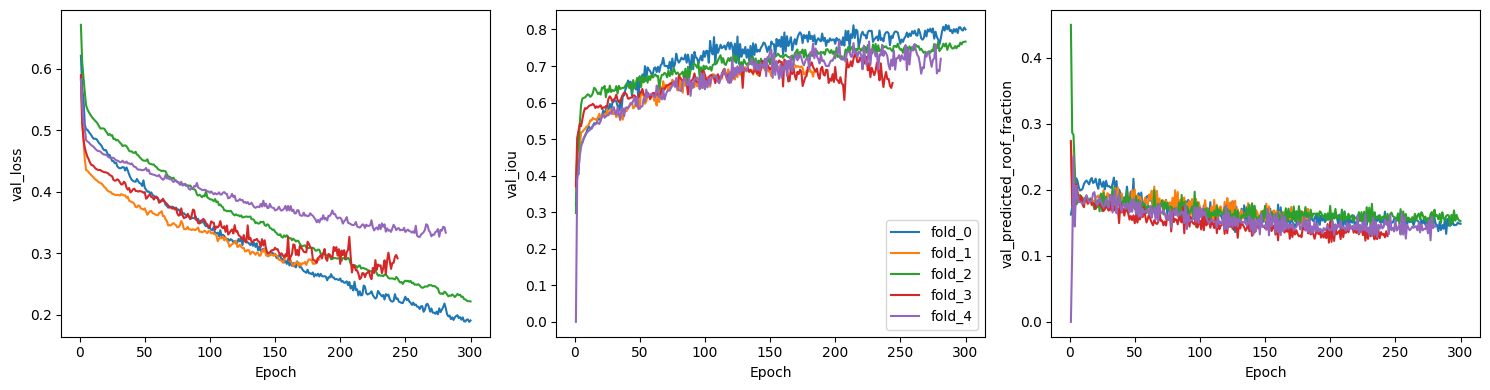

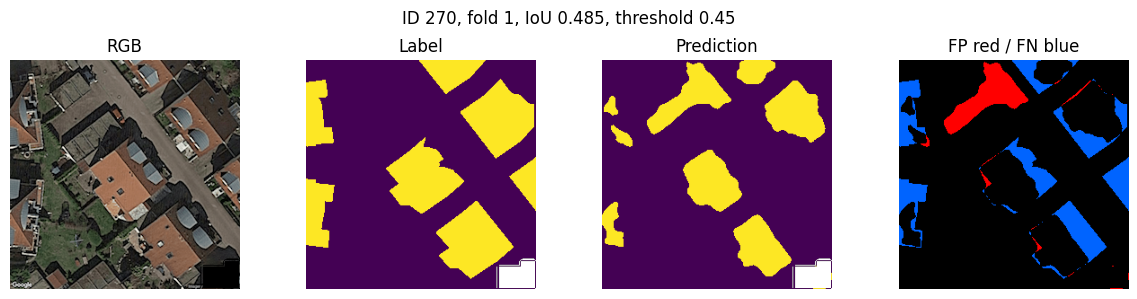

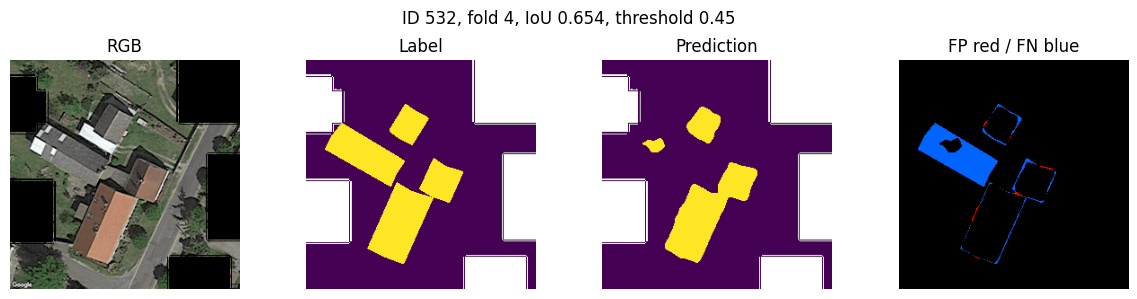

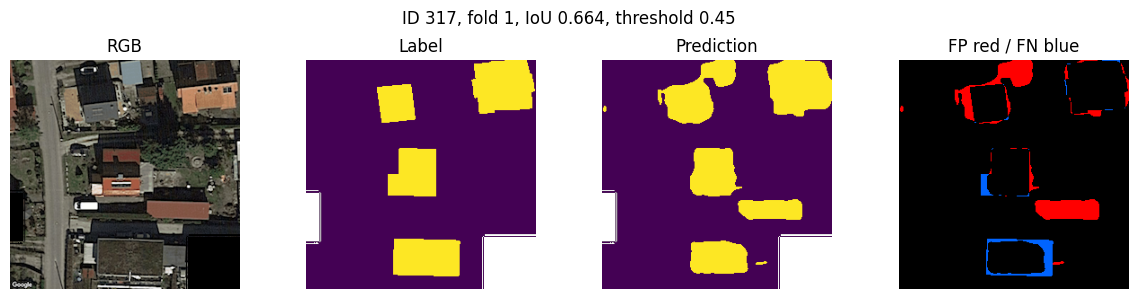

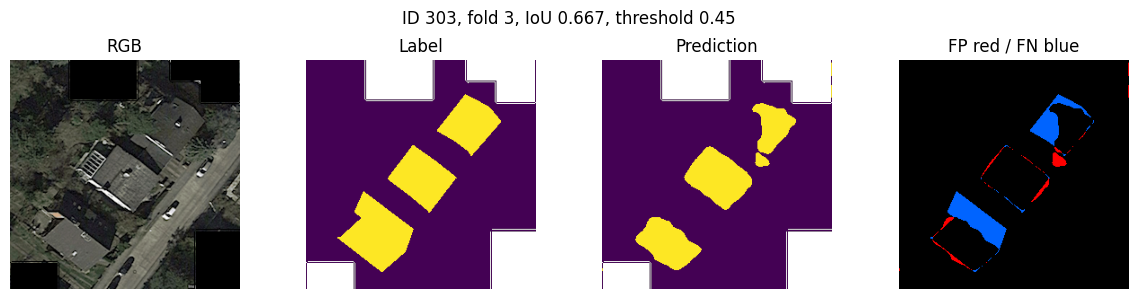

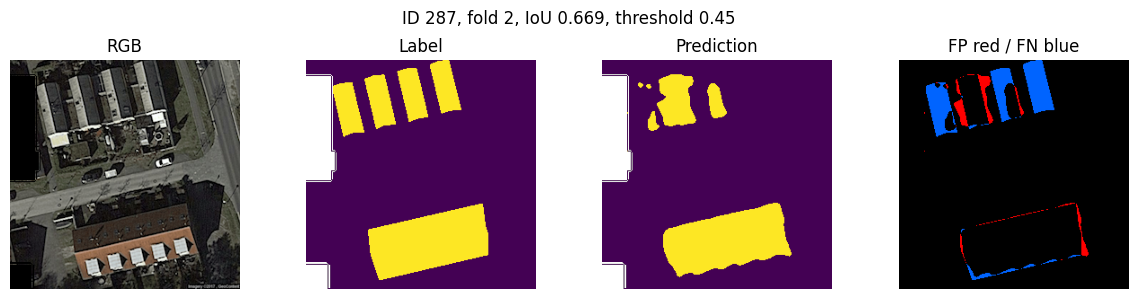

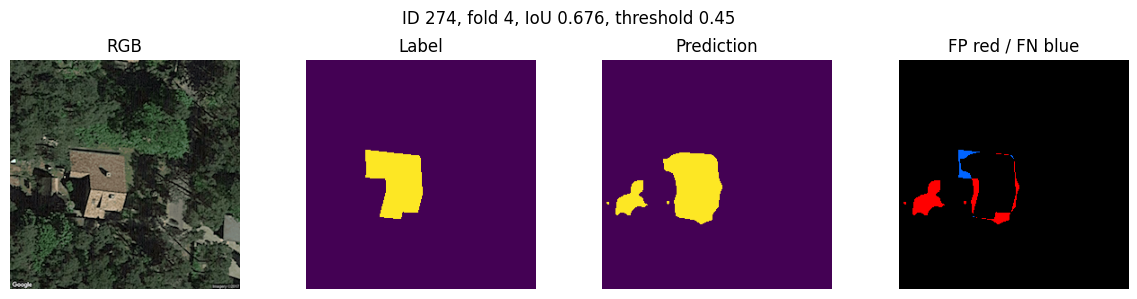

In [26]:
plot_history(paths, RUN_NAME)
show_predictions(paths, RUN_NAME, limit=6)

## Paired comparison

Run after both experiments finish all five folds. Compare per-image changes and inspect failure cases; a small average improvement with 24 images is not sufficient evidence of a reliable benefit. Neither experiment uses the five unlabelled images for tuning.

In [28]:
comparison = compare_runs(paths, baseline='baseline_cv_loss_threshold045_300epoch', crop=RUN_NAME)
comparison

{
  "run_name": "baseline_cv_loss_threshold045_300epoch",
  "threshold": 0.45,
  "complete": true,
  "images": 24,
  "folds_completed": 5,
  "scope": "Development CV; checkpoint selection uses these validation folds.",
  "macro": {
    "iou": 0.7305191358978904,
    "dice": 0.8397952117156082,
    "precision": 0.8405331570769284,
    "recall": 0.8522114077859744
  },
  "fold_iou": [
    0.7536140460429419,
    0.6956350802032598,
    0.7484461392829915,
    0.6827695881063056,
    0.7767498078829629
  ]
}
{
  "run_name": "crop_cv_loss_t045_300epoch",
  "threshold": 0.45,
  "complete": true,
  "images": 24,
  "folds_completed": 5,
  "scope": "Development CV; checkpoint selection uses these validation folds.",
  "macro": {
    "iou": 0.7510787571610473,
    "dice": 0.8546240061630535,
    "precision": 0.8515521251558832,
    "recall": 0.8700433586525484
  },
  "fold_iou": [
    0.8053989612085976,
    0.7081016545260441,
    0.766891113997964,
    0.7257017496304293,
    0.76016434725171

[{'id': '121',
  'fold': 0,
  'baseline_iou': 0.838090295796575,
  'crop_iou': 0.8604130380691715,
  'delta_iou': 0.022322742272596452},
 {'id': '241',
  'fold': 0,
  'baseline_iou': 0.7973434185038281,
  'crop_iou': 0.8089123867069486,
  'delta_iou': 0.011568968203120589},
 {'id': '270',
  'fold': 1,
  'baseline_iou': 0.4801162509082102,
  'crop_iou': 0.4852420306965762,
  'delta_iou': 0.005125779788365981},
 {'id': '272',
  'fold': 4,
  'baseline_iou': 0.8152847447624668,
  'crop_iou': 0.8221585859583292,
  'delta_iou': 0.006873841195862429},
 {'id': '274',
  'fold': 4,
  'baseline_iou': 0.7387735393529696,
  'crop_iou': 0.6760327112602222,
  'delta_iou': -0.06274082809274739},
 {'id': '284',
  'fold': 3,
  'baseline_iou': 0.6055153530217093,
  'crop_iou': 0.6823467230443975,
  'delta_iou': 0.07683137002268814},
 {'id': '287',
  'fold': 2,
  'baseline_iou': 0.5806239015817223,
  'crop_iou': 0.6694572748267898,
  'delta_iou': 0.08883337324506757},
 {'id': '300',
  'fold': 3,
  'baseli

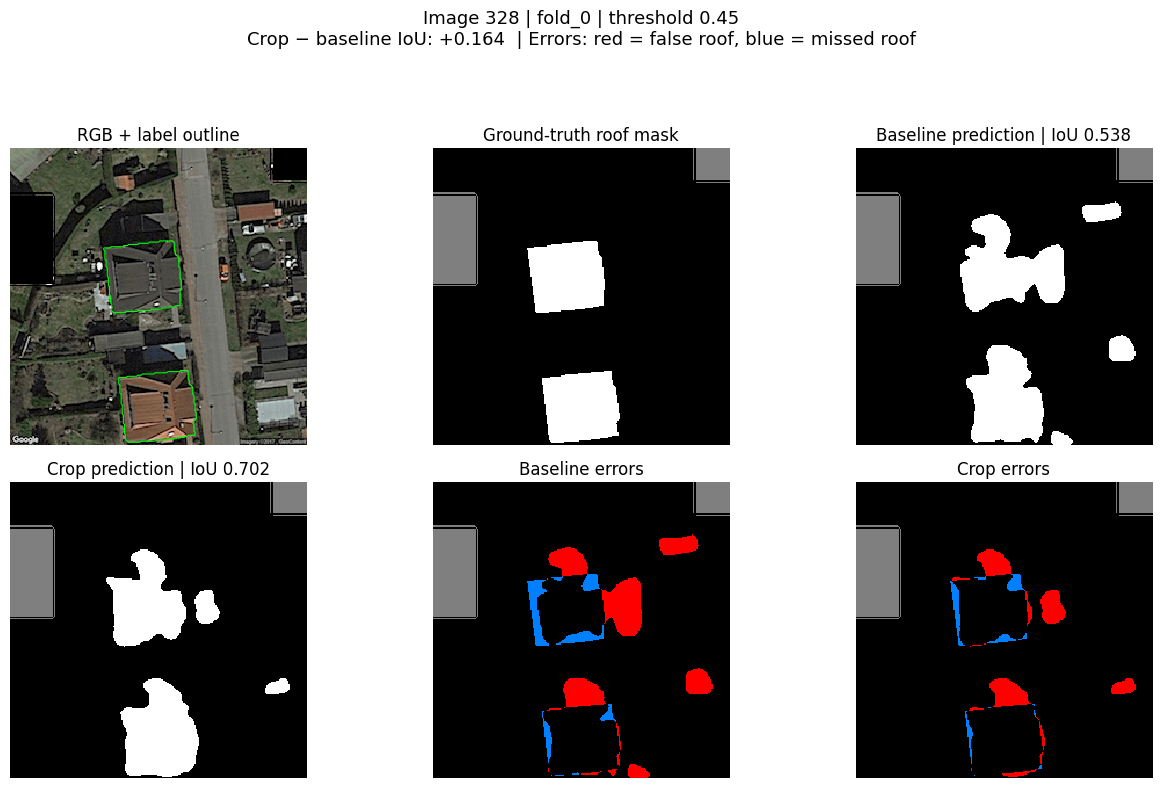

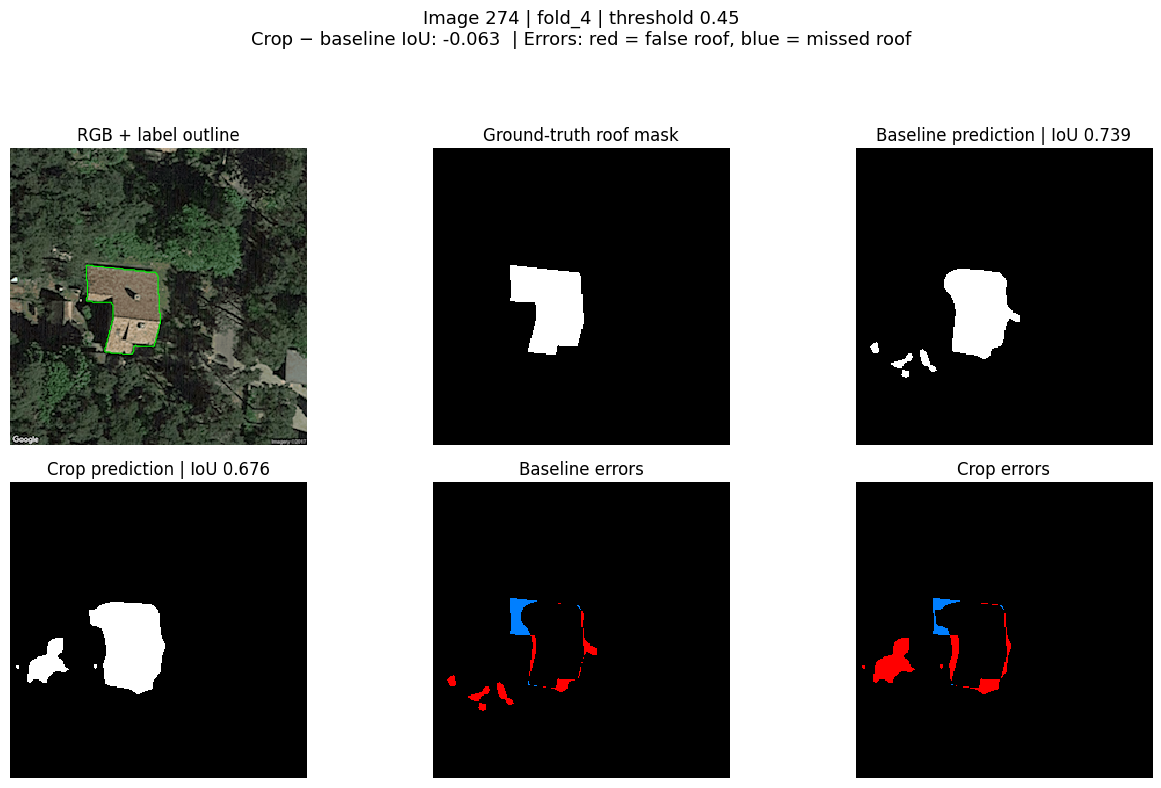

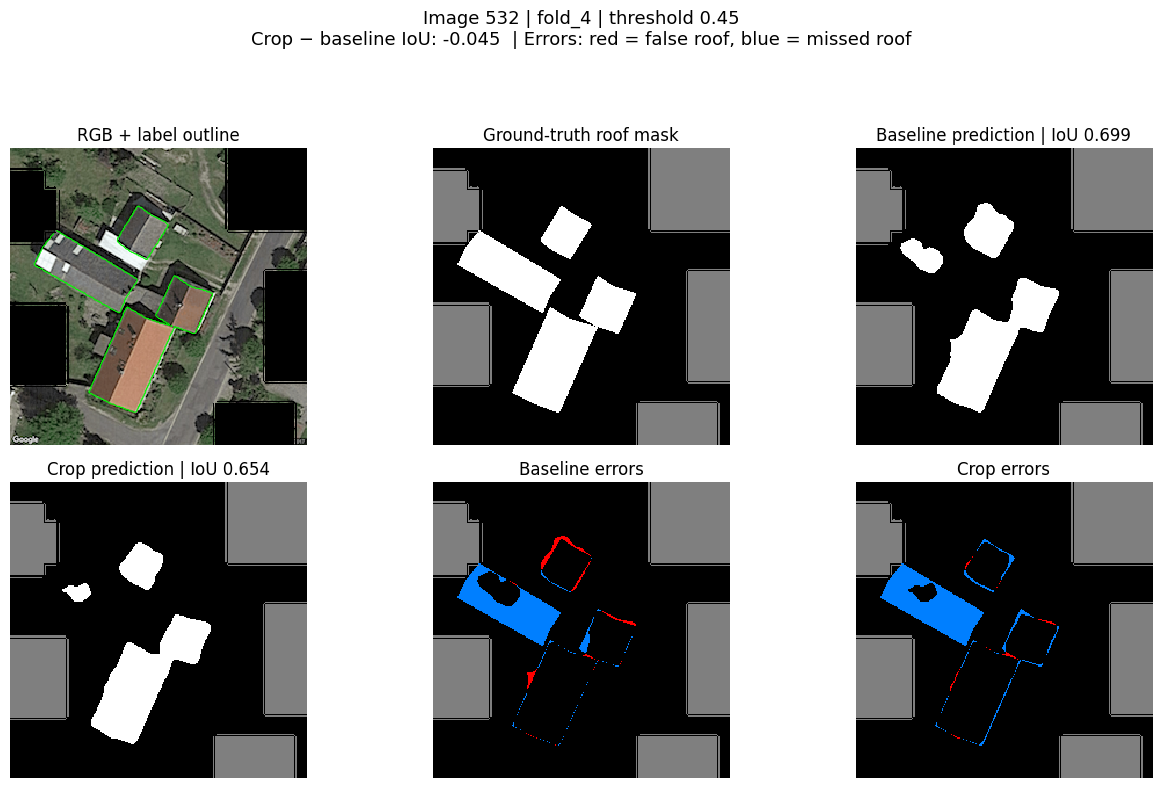

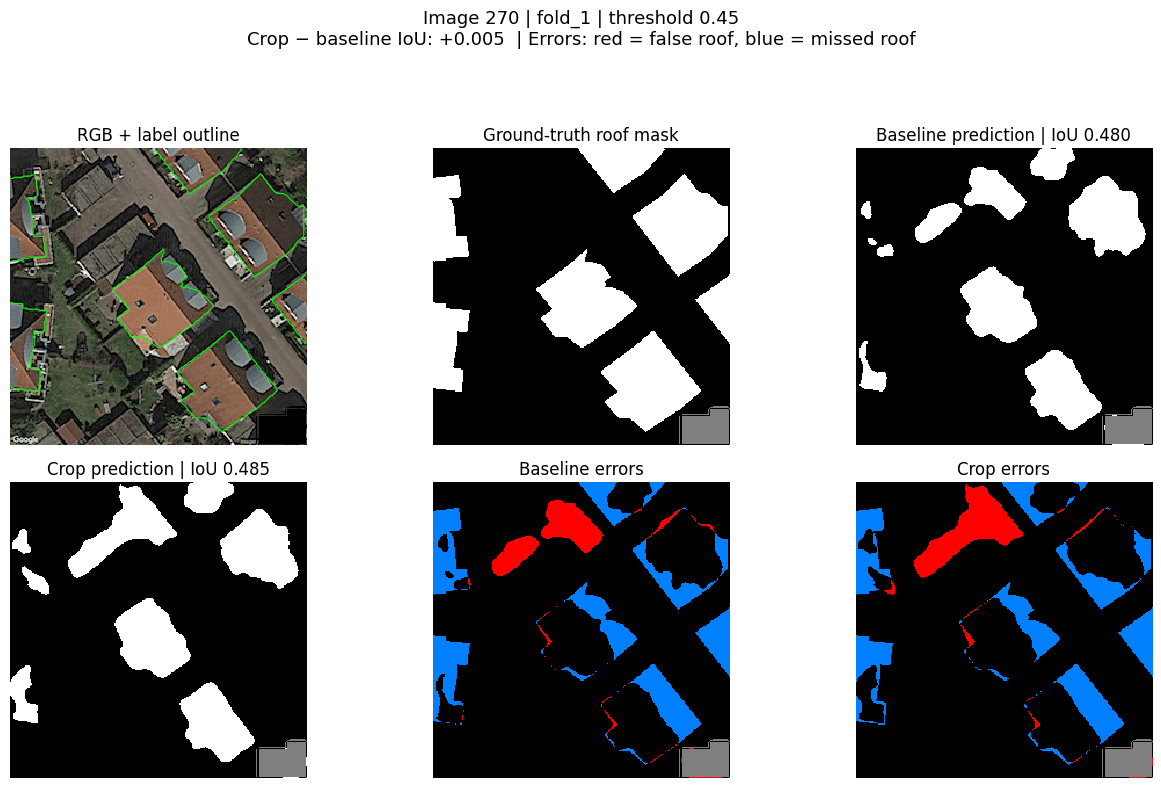

In [29]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

BASELINE_RUN = "baseline_cv_loss_threshold045_300epoch"  # Change if needed
CROP_RUN = "crop_cv_loss_t045_300epoch"          # Change if needed
THRESHOLD = 0.45
IMAGE_IDS = ["328", "274", "532", "270"]


def load_prediction(run_name, image_id):
    files = list(
        (paths.reports_dir / run_name).glob(f"fold_*/{image_id}.npz")
    )
    if len(files) != 1:
        raise FileNotFoundError(
            f"Expected one prediction for image {image_id} "
            f"in {run_name}; found {len(files)}."
        )

    with np.load(files[0]) as data:
        return (
            data["probability"].copy(),
            data["target"].astype(bool),
            data["valid"].astype(bool),
            files[0].parent.name,
        )


def calculate_iou(prediction, target, valid):
    intersection = (prediction & target & valid).sum()
    union = ((prediction | target) & valid).sum()
    return intersection / union if union else 1.0


def mask_image(mask, valid):
    # White = roof, black = background, grey = invalid.
    image = np.repeat(mask[..., None], 3, axis=2).astype(float)
    image[~valid] = 0.5
    return image


def error_image(prediction, target, valid):
    image = np.zeros((*target.shape, 3), dtype=float)
    image[prediction & ~target & valid] = [1, 0, 0]      # False positive
    image[~prediction & target & valid] = [0, 0.5, 1]   # False negative
    image[~valid] = 0.5
    return image


for image_id in IMAGE_IDS:
    base_prob, target, valid, base_fold = load_prediction(
        BASELINE_RUN, image_id
    )
    crop_prob, crop_target, crop_valid, crop_fold = load_prediction(
        CROP_RUN, image_id
    )

    if (
        base_fold != crop_fold
        or not np.array_equal(target, crop_target)
        or not np.array_equal(valid, crop_valid)
        or base_prob.shape != crop_prob.shape
    ):
        raise ValueError(f"Fold, label, or shape mismatch for {image_id}")

    with Image.open(
        paths.prepared_data_dir / "rgb" / f"{image_id}.png"
    ) as image:
        rgb = np.asarray(image.convert("RGB"))

    base_prediction = base_prob >= THRESHOLD
    crop_prediction = crop_prob >= THRESHOLD

    base_iou = calculate_iou(base_prediction, target, valid)
    crop_iou = calculate_iou(crop_prediction, target, valid)

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))

    panels = [
        (rgb, "RGB + label outline"),
        (mask_image(target, valid), "Ground-truth roof mask"),
        (mask_image(base_prediction, valid),
         f"Baseline prediction | IoU {base_iou:.3f}"),
        (mask_image(crop_prediction, valid),
         f"Crop prediction | IoU {crop_iou:.3f}"),
        (error_image(base_prediction, target, valid), "Baseline errors"),
        (error_image(crop_prediction, target, valid), "Crop errors"),
    ]

    for ax, (image, title) in zip(axes.flat, panels):
        ax.imshow(image, interpolation="nearest")
        ax.set_title(title)
        ax.axis("off")

    # Label outlines help reveal misalignment with the actual roofs.
    outlined_target = np.ma.masked_where(~valid, target.astype(float))
    if target[valid].any() and (~target[valid]).any():
        axes[0, 0].contour(
            outlined_target, levels=[0.5],
            colors=["lime"], linewidths=0.8,
        )

    fig.suptitle(
        f"Image {image_id} | {base_fold} | threshold {THRESHOLD}\n"
        f"Crop − baseline IoU: {crop_iou - base_iou:+.3f} "
        " | Errors: red = false roof, blue = missed roof",
        fontsize=13,
    )
    plt.tight_layout(rect=(0, 0, 1, 0.92))
    plt.show()

## Saved outputs

Under `MODELS_DIR/<run>/fold_N/`: `best.pt` and `last.pt` (model + optimizer/RNG state for resume). Under `REPORTS_DIR/<run>/`: experiment configuration, data/code fingerprints, learning curves, per-image IoU/Dice/precision/recall, probability maps and aggregate metrics.

The baseline notebook should finish first. After the crop comparison, review errors and choose the training recipe before fitting a final model or predicting the five unlabelled images.

References: [Colab runtime and persistence](https://research.google.com/colaboratory/faq.html), [PyTorch installation](https://pytorch.org/get-started/locally/).

[Colab VS Code user guide](https://github.com/googlecolab/colab-vscode/wiki/User-Guide).

## Evaluate an already trained run without retraining

Run only the installation/setup/import cells above, then the cell below. It reads saved probability maps, preserves original metrics and weights, and writes separate threshold reports. Do not run the training cell to re-score an old run. Learning curves retain the threshold used during training.

In [ ]:
EXISTING_RUN = 'crop_cv_loss'
THRESHOLD = 0.45
threshold_summary = evaluate_saved_predictions(paths, EXISTING_RUN, threshold=THRESHOLD)
show_predictions(paths, EXISTING_RUN, threshold=THRESHOLD)